In [1]:
import sys
import os
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore")

from collections import defaultdict, deque # deque is nodig voor histwrapper
from gymnasium import spaces, Wrapper # Wrapper is de basisklasse voor custom wrappers
import matplotlib.pyplot as plt
import gymnasium as gym


sys.path.append(os.path.expanduser("~/src/swingup/q_learning"))
from UnbalancedDiskDiscrete import UnbalancedDisk

In [2]:
class UnbalancedDiskResetWrapper(gym.Wrapper):
    """
    Wrapper om de reset methode van de omgeving te normaliseren
    voor compatibiliteit met verschillende Gymnasium versies.
    """
    def __init__(self, env): super().__init__(env)
    def reset(self, *, seed=None, options=None):
        try: obs, info = self.env.reset(seed=seed)
        except TypeError: obs, info = self.env.reset();
        return obs, info

class Discretize_obs(gym.Wrapper):
    """
    Discretiseert [theta, omega] voor tabulaire Q-learning.
    Hoek: NIET-uniform -> FIJN vlak bij de top (phi=0), grof bij de bodem (phi=+-pi).
    Snelheid (omega): uniform over de observation_space-range.
    nvec=[<genegeerd voor hoek>, n_omega].  Fijnheid via fine_w / fine_res / coarse_res.
    LET OP: exact dezelfde discretize() moet in runExp.py staan, anders mismatch bij deployment!
    """
    def __init__(self, env, nvec, fine_w=0.40, fine_res=0.025, coarse_res=0.10):
        super(Discretize_obs, self).__init__(env)
        o = env.observation_space
        self.omega_low  = float(o.low[1]);  self.omega_high = float(o.high[1])
        self.n_omega = int(np.array(nvec).flatten()[1])
        # niet-uniforme, top-gecentreerde hoek-edges
        pos = list(np.arange(0.0, fine_w, fine_res)) + list(np.arange(fine_w, np.pi, coarse_res)) + [np.pi]
        self.angle_edges = np.array(sorted(set([-e for e in pos] + pos)))
        self.n_angle = len(self.angle_edges) - 1
        self.observation_space = gym.spaces.MultiDiscrete([self.n_angle, self.n_omega])

    def discretize(self, observation):
        th = float(observation[0]); om = float(observation[1])
        phi = (th % (2 * np.pi)) - np.pi                                   # 0 = top, +-pi = bodem
        a = int(np.clip(np.searchsorted(self.angle_edges, phi, side='right') - 1, 0, self.n_angle - 1))
        om = np.clip(om, self.omega_low, self.omega_high)
        b = int(np.clip((om - self.omega_low) / (self.omega_high - self.omega_low) * self.n_omega, 0, self.n_omega - 1))
        return (a, b)

    def step(self, action):
        observation, reward, terminated, truncated, info = self.env.step(action)
        return self.discretize(observation), reward, terminated, truncated, info

    def reset(self, *args, **kwargs):
        obs, info = self.env.reset()
        return self.discretize(obs), info


def roll_mean(ar,start=2000,N=50): #smoothing if needed
    """
    Berekent een exponentieel voortschrijdend gemiddelde.
    `start` is de initiële waarde voor het gemiddelde.
    `N` bepaalt de gladheid (hoe groter N, hoe gladder).
    """
    s = 1-1/N
    k = start
    out = np.zeros(ar.shape)
    for i,a in enumerate(ar):
        k = s*k + (1-s)*a
    return out

def argmax(a):
    """
    Retourneert een willekeurige index van de maximale waarde in een array.
    Dit voorkomt een bias bij meerdere gelijke maximale waarden (tie-breaking).
    """
    a = np.array(a)
    return np.random.choice(np.arange(len(a),dtype=int)[a==np.max(a)])




In [3]:
def Qlearn(env, nsteps=5000, nvec_angle = 360 , nvec_rps = 30 ,callbackfeq=5000, alpha=0.15, gamma=0.99, avg_window=8, checkpoint_name='best_Qmat.pkl', callback=None):
    import pickle
    Qmat = defaultdict(float)
    env_time = env

    while not isinstance(env_time,gym.wrappers.TimeLimit):
        if hasattr(env_time, 'env'):
            env_time = env_time.env
        else:
            print("Waarschuwing: Kan geen gym.wrappers.TimeLimit vinden in de omgeving. _elapsed_steps is mogelijk niet beschikbaar.")
            break
            
    ep_lengths = []
    ep_lengths_steps = []
    ep_rewards = []
    obs, info = env.reset()
    current_episode_reward = 0.0
    best_avg_reward = -float('inf')
    best_Qmat_to_save = None
    from collections import deque
    recent_rewards = deque(maxlen=avg_window)  # voortschrijdend gemiddelde venster

    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Qmat_loaded_at_start = pickle.load(f)
                Qmat.update(Qmat_loaded_at_start)
            print(f"Succesvol initiële Qmat geladen van {checkpoint_name}. Training wordt voortgezet.")
        except Exception as e:
            print(f"Waarschuwing: Kon initiële Qmat niet laden van {checkpoint_name}: {e}. Starten met een lege Qmat.")
    else:
        print(f"Geen initieel checkpoint gevonden op {checkpoint_name}. Starten met een lege Qmat.")
            
    for z in range(nsteps):
        # eps = 0.6 - 0.55 * z / (nsteps - 1)

        # eps = max(0.05,
        #         1 - 0.95 * z / (nvec_angle * nvec_rps * 3 - 1),
        #         0.3 - 0.25 * z * 1.4 / (nsteps - 1))

        # eps = max(
        #     0.05,  # Minimum threshold for eps
        #     1 - 0.99 * z / (nvec_angle * nvec_rps * 2.5 - 1),         # First decay function
        #     0.3 - 0.15 * z * 1.4 / (nsteps - 1) ,                     # Second decay function
        #     0.4 - 0.15 * z *3/ (nsteps - 1)
        # )
        eps = max(
            0.01,  # Minimum threshold for eps
            # 
            # exponentiële decay functie die snel begint en langzaam afneemt, met een asymptoot bij 0.05
            0.7 * np.exp(-5 * z / nsteps) + 0.01
        )

        # Dalende learning rate: grote stappen vroeg (leren), kleine stappen laat (vastzetten)
        alpha_now = max(0.015, alpha * (1 - z / nsteps))
        # Curriculum op de startpositie: vroeg wijd (overal leren), laat smal -> onderaan in rust
        # (eindgoal op de fysieke opstelling = swing-up vanaf stilstand onderaan)
        env.unwrapped.start_scale = max(0.01, 1 - z / nsteps)

        if np.random.uniform()<eps:
            action = env.action_space.sample()
        else:
            action = argmax([Qmat[(obs, i)] for i in range(env.action_space.n)])
            
        obs_new, reward, terminated, truncated, info = env.step(action)
        current_episode_reward += reward

        if callback and z % callbackfeq == 0:
            callback(Qmat, z, env)

        if terminated or truncated:
            A = reward - Qmat[(obs, action)]
            Qmat[(obs, action)] += alpha_now * A
            
            print_status_message = ""
            if terminated:
                print_status_message = f"{env_time._elapsed_steps}, stap {z+1}. Totale Beloning: {current_episode_reward:.2f}"
            elif truncated:
                print_status_message = f"{env_time._elapsed_steps}, stap {z+1}. Totale Beloning: {current_episode_reward:.2f}"
            
            
            ep_lengths.append(env_time._elapsed_steps)
            ep_lengths_steps.append(z)
            ep_rewards.append(current_episode_reward)
            recent_rewards.append(current_episode_reward)
            obs, info = env.reset()
            # Save op basis van het VOORTSCHRIJDEND GEMIDDELDE van de laatste avg_window episodes.
            # Robuuster dan opslaan op 1 (geluks)episode -> checkpoint = consistent goede policy.
            if len(recent_rewards) == avg_window:
                running_avg = float(np.mean(recent_rewards))
                if running_avg > best_avg_reward:
                    best_avg_reward = running_avg
                    best_Qmat_to_save = Qmat.copy()
                    try:
                        with open(checkpoint_name, 'wb') as fpkl:
                            pickle.dump(best_Qmat_to_save, fpkl)
                        print(f"#################################\n NIEUWE BESTE GEM. BELONING (laatste {avg_window} ep): {running_avg:.2f}, opgeslagen naar {checkpoint_name}\n#################################")
                    except Exception as e:
                        print(f"Fout bij opslaan Qmat: {e}")
            current_episode_reward = 0.0
            print(print_status_message)

        else:
            A = reward + gamma * max(Qmat[(obs_new, action_next)] for action_next in range(env.action_space.n)) - Qmat[(obs, action)]
            Qmat[(obs, action)] += alpha_now * A
            obs = obs_new

    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Qmat_final = pickle.load(f)
            print(f"Laden van de uiteindelijke beste Qmat (gemiddelde beloning: {best_avg_reward:.2f}) van {checkpoint_name}")
            return Qmat_final, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
        except Exception as e:
            print(f"Fout bij laden van de uiteindelijke beste Qmat van {checkpoint_name}: {e}. Huidige Qmat wordt geretourneerd.")
    elif best_Qmat_to_save is not None:
        print("Geen checkpointbestand gevonden, maar best_Qmat_to_save was ingesteld. Deze wordt geretourneerd.")
        return best_Qmat_to_save, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
    else:
        print("Geen beste Qmat is opgeslagen tijdens training (mogelijk niet genoeg episodes of geen verbetering). Huidige Qmat wordt geretourneerd.")

    return Qmat, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)


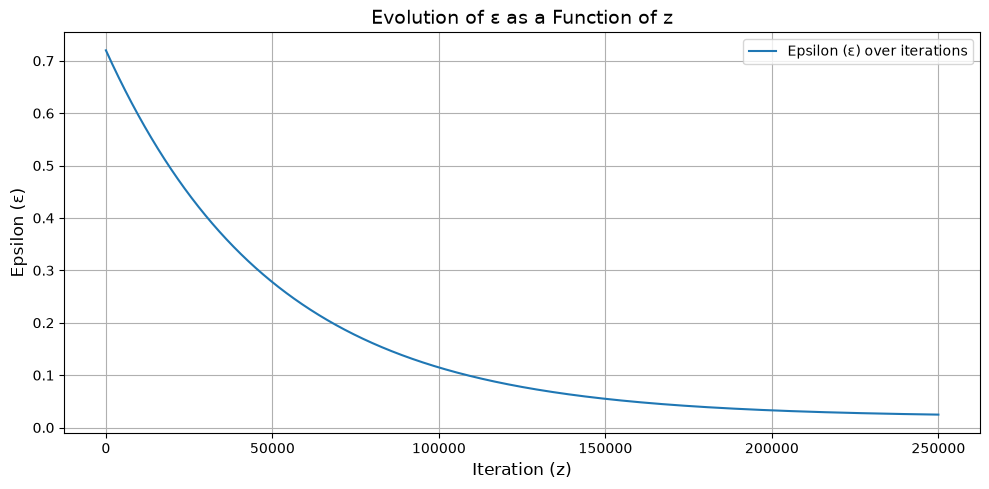

In [4]:
import matplotlib.pyplot as plt

# Define parameters
n_steps = 250_000                # Total number of steps (samples)
n_vec_angle = 360                  # Number of angular divisions
n_vec_rps = 30                     # Rotations per second

# Create the z-axis values
z_values = range(n_steps)

# Compute epsilon values with piecewise decay logic
# eps_values = [
#     max(
#         0.05,  # Minimum threshold for eps
#         1 - 0.99 * z / (n_vec_angle * n_vec_rps * 2.5 - 1),         # First decay function
#         0.3 - 0.15 * z * 1.4 / (n_steps - 1) ,                     # Second decay function
#         0.4 - 0.15 * z *3/ (n_steps - 1)
#     )
#     for z in z_values
# ]


eps_values = [
    max(
        0.02,  # Minimum threshold for eps
        # exponentiële decay functie die snel begint en langzaam afneemt, met een asymptoot bij 0.05
        # 0.3 * np.exp(-5 * z / n_steps) + 0.05
        0.7 * np.exp(-5 * z / (n_steps)) + 0.02
    )
    for z in z_values
]


# eps_values = [
#     max(0.05,
#                 1 - 0.95 * z / (n_vec_angle * n_vec_rps * 3 - 1),
#                 0.3 - 0.25 * z * 1.4 / (n_vec_rps - 1))
#     for z in z_values
# ]

# Plot the evolution of epsilon over z
plt.figure(figsize=(10, 5))
plt.plot(z_values, eps_values, label="Epsilon (ε) over iterations")
plt.xlabel("Iteration (z)", fontsize=12)
plt.ylabel("Epsilon (ε)", fontsize=12)
plt.title("Evolution of ε as a Function of z", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [5]:
# --- Hoofddeel van het Script: Training en Evaluatie ---

checkpoint_filename = 'Q_learning_DATA_v61.pkl' # De bestandsnaam voor jouw opgeslagen Q-tabel

# --- Trainingsfase ---
print("\n--- START TRAINING ---")
nvec_angle = 120
nvec_rps = 50
max_episode_steps_train = 300
Qmats = {}
for nvec in [20]:
    env_train = UnbalancedDisk(dt=0.025, umax=3., render_mode=None)
    env_train = UnbalancedDiskResetWrapper(env_train)
    env_train = gym.wrappers.TimeLimit(env_train, max_episode_steps=max_episode_steps_train)
    env_train = Discretize_obs(env_train, nvec=[nvec_angle,nvec_rps])

    print(f'nvec={nvec}')
    Qmat_trained, ep_lengths_steps, ep_lengths, ep_rewards = Qlearn(
        env_train,
        nsteps=230_000, # Aantal trainingsstappen
        nvec_angle = nvec_angle,
        nvec_rps = nvec_rps,
        callbackfeq=5000, # Frequentie voor evaluatie en potentieel opslaan
        checkpoint_name=checkpoint_filename # De gedefinieerde bestandsnaam
    )
    Qmats[nvec] = Qmat_trained
    env_train.close()

if os.path.exists(checkpoint_filename):
    print(f"\nCheck: Checkpoint file '{checkpoint_filename}' found on disk.")
    try:
        import pickle
        with open(checkpoint_filename, 'rb') as f:
            loaded_Qmat_final_check = pickle.load(f)
        print(f"Successfully loaded Qmat from '{checkpoint_filename}' for final check. Size: {len(loaded_Qmat_final_check)} entries.")
    except Exception as e:
        print(f"Error loading saved Qmat for final check: {e}")
else:
    print(f"\nCheck: Checkpoint file '{checkpoint_filename}' NOT found on disk.")





--- START TRAINING ---
nvec=20
Succesvol initiële Qmat geladen van Q_learning_DATA_v61.pkl. Training wordt voortgezet.
300, stap 300. Totale Beloning: -86.99
300, stap 600. Totale Beloning: -87.29
300, stap 900. Totale Beloning: -78.88
300, stap 1200. Totale Beloning: -76.58
300, stap 1500. Totale Beloning: -62.32
300, stap 1800. Totale Beloning: -67.46
300, stap 2100. Totale Beloning: -103.90
#################################
 NIEUWE BESTE GEM. BELONING (laatste 8 ep): -80.04, opgeslagen naar Q_learning_DATA_v61.pkl
#################################
300, stap 2400. Totale Beloning: -76.91
#################################
 NIEUWE BESTE GEM. BELONING (laatste 8 ep): -77.67, opgeslagen naar Q_learning_DATA_v61.pkl
#################################
300, stap 2700. Totale Beloning: -68.06
#################################
 NIEUWE BESTE GEM. BELONING (laatste 8 ep): -75.59, opgeslagen naar Q_learning_DATA_v61.pkl
#################################
300, stap 3000. Totale Beloning: -70.64
##

Laatste 10 episode beloningen: [385.59185945  61.37463346 101.65642994 204.96234818  78.24122072
 190.05119549  29.9440965  168.73103235  21.4389861  176.65730378]


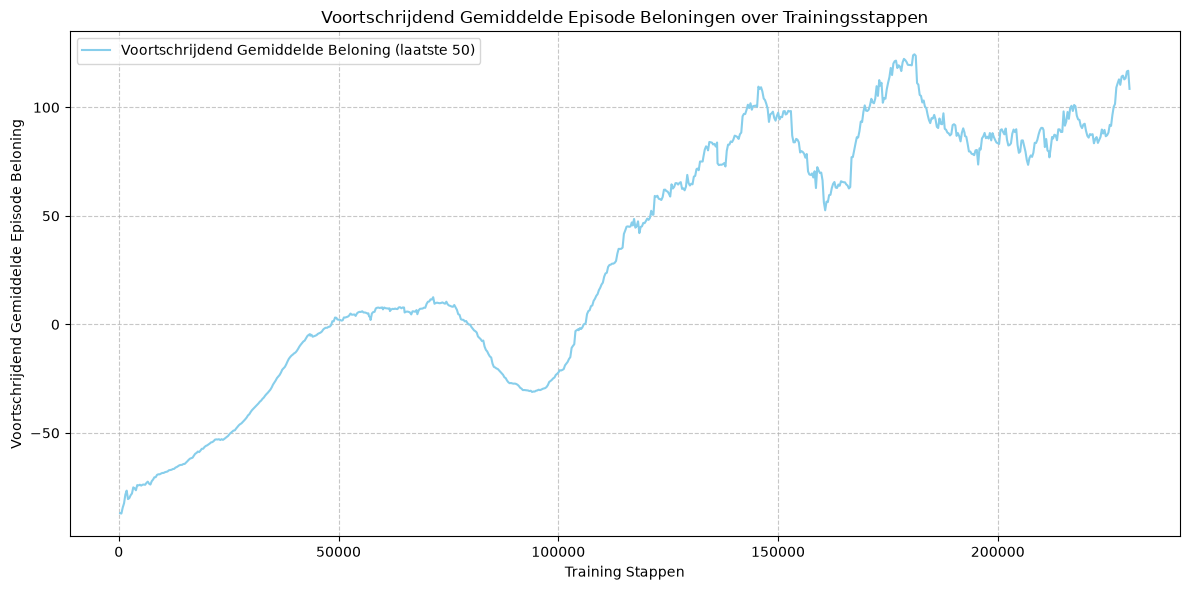

In [6]:
from matplotlib import pyplot as plt
import numpy as np
print(f"Laatste 10 episode beloningen: {ep_rewards[-10:]}")
N_ROLLING_MEAN = 50 # Je kunt dit aanpassen naar behoefte
rolled_rewards = []
for i in range(len(ep_rewards)):
    start_index = max(0, i - N_ROLLING_MEAN + 1)
    rolled_rewards.append(np.mean(ep_rewards[start_index:i+1]))

plt.figure(figsize=(12, 6)) # Optioneel: Maak de plot wat groter
plt.plot(ep_lengths_steps, rolled_rewards, label=f'Voortschrijdend Gemiddelde Beloning (laatste {N_ROLLING_MEAN})', color='skyblue')
plt.legend()
plt.xlabel("Training Stappen")
plt.ylabel("Voortschrijdend Gemiddelde Episode Beloning")
plt.title("Voortschrijdend Gemiddelde Episode Beloningen over Trainingsstappen")
plt.grid(True, linestyle='--', alpha=0.7) # Voeg een subtiel raster toe
plt.tight_layout() # Zorgt ervoor dat alle elementen goed passen
plt.show()

In [7]:
# --- Evaluatie Fase: REPRODUCEERBAAR (deterministisch + vaste start onderaan) ---
print("\n--- START EVALUATION WITH BEST MODEL ---")
import pickle

checkpoint_filename = 'Q_learning_DATA_v61.pkl'
nvec_angle = 120                 # MOET gelijk zijn aan de training-cel
nvec_rps   = 50                  # MOET gelijk zijn aan de training-cel
eval_max_episode_steps = 300     # zelfde als tijdens training
TOP_TOL = 0.30                   # rad (~17 graden) -> "bij de top"
NUM_EVAL_EPISODES = 50           # meer episodes -> stabielere statistiek
EVAL_SEED = 0                    # vaste seed -> elke run identieke ruis/resultaat

best_Qmat = None
if os.path.exists(checkpoint_filename):
    with open(checkpoint_filename, 'rb') as f:
        best_Qmat = pickle.load(f)
    print(f"Loaded best Qmat from '{checkpoint_filename}' ({len(best_Qmat)} entries).")
else:
    print(f"Error: checkpoint '{checkpoint_filename}' not found. Train eerst.")


def make_eval_env(render_mode):
    e = UnbalancedDisk(dt=0.025, umax=3., render_mode=render_mode)
    e = UnbalancedDiskResetWrapper(e)
    e = gym.wrappers.TimeLimit(e, max_episode_steps=eval_max_episode_steps)
    e = Discretize_obs(e, nvec=[nvec_angle, nvec_rps])
    return e


def greedy_action(Qmat, obs, n):
    # DETERMINISTISCH: np.argmax pakt altijd de eerste max (geen willekeurige tie-break)
    return int(np.argmax([Qmat.get((obs, a), 0.0) for a in range(n)]))


def run_episode(env, Qmat, start=(0.0, 0.0), render=False, fps=30):
    """Eén greedy episode vanaf een VASTE start (default: stilstand onderaan)."""
    base = env.unwrapped
    base.set_th, base.set_omega = float(start[0]), float(start[1])   # forceer vaste startpositie
    obs, info = env.reset()
    base.set_th, base.set_omega = None, None                         # herstel
    total_r, steps, done, top_steps = 0.0, 0, False, 0
    while not done:
        action = greedy_action(Qmat, obs, env.action_space.n)
        obs, reward, terminated, truncated, info = env.step(action)
        total_r += reward
        steps += 1
        done = terminated or truncated
        err_top = abs(((base.th - np.pi + np.pi) % (2 * np.pi)) - np.pi)
        if err_top < TOP_TOL:
            top_steps += 1
        if render:
            env.render()
            time.sleep(1 / fps)
    ended_at_top = abs(((base.th - np.pi + np.pi) % (2 * np.pi)) - np.pi) < TOP_TOL
    return total_r, steps, top_steps / max(steps, 1), ended_at_top


if best_Qmat is not None:
    # Elke episode start vanaf stilstand onderaan (th=0, omega=0) -> zuivere swing-up test
    START = (0.0, 0.0)

    # 1) Statistische evaluatie (geen render -> snel). Seed -> volledig reproduceerbaar.
    np.random.seed(EVAL_SEED)
    env_stats = make_eval_env(render_mode=None)
    rewards, lengths, toptime, ended = [], [], [], []
    for _ in range(NUM_EVAL_EPISODES):
        r, l, ft, et = run_episode(env_stats, best_Qmat, start=START, render=False)
        rewards.append(r); lengths.append(l); toptime.append(ft); ended.append(et)
    env_stats.close()
    rewards = np.array(rewards); lengths = np.array(lengths); toptime = np.array(toptime)

    print(f"\n--- EVALUATION RESULTS over {NUM_EVAL_EPISODES} greedy episodes (deterministisch, start onderaan) ---")
    print(f"Reward       : mean {rewards.mean():8.2f} | std {rewards.std():7.2f} | "
          f"median {np.median(rewards):8.2f} | min {rewards.min():8.2f} | max {rewards.max():8.2f}")
    print(f"Length       : mean {lengths.mean():8.1f} | min {int(lengths.min())} | max {int(lengths.max())}")
    print(f"Tijd bij top : mean {100*toptime.mean():5.1f}%   <-- ECHTE kwaliteit (niet de reward)")
    print(f"Succes (eindigt bij top): {100*np.mean(ended):5.1f}% van de episodes")

    # 2) Een paar episodes met render om te kijken (ook vanaf onderaan)
    num_watch = 3
    np.random.seed(EVAL_SEED)
    env_watch = make_eval_env(render_mode='human')
    for i in range(num_watch):
        r, l, ft, et = run_episode(env_watch, best_Qmat, start=START, render=True)
        print(f"Watch episode {i+1}: length={l}, reward={r:.2f}, tijd-bij-top={100*ft:.0f}%")
    env_watch.close()
else:
    print("No best Qmat available for evaluation.")
# --- Einde van het Script ---



--- START EVALUATION WITH BEST MODEL ---
Loaded best Qmat from 'Q_learning_DATA_v61.pkl' (49668 entries).

--- EVALUATION RESULTS over 50 greedy episodes (deterministisch, start onderaan) ---
Reward       : mean   159.67 | std  143.85 | median   133.76 | min    -2.77 | max   590.34
Length       : mean    300.0 | min 300 | max 300
Tijd bij top : mean  22.7%   <-- ECHTE kwaliteit (niet de reward)
Succes (eindigt bij top):  70.0% van de episodes
Watch episode 1: length=300, reward=590.34, tijd-bij-top=51%
Watch episode 2: length=300, reward=143.82, tijd-bij-top=30%
Watch episode 3: length=300, reward=490.77, tijd-bij-top=61%
